In [1]:
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn.functional as F

device = torch.device('cpu')
print(f"Using device: {device}")

Using device: cpu


In [2]:
features_path = ('Data/features_normalized.nc')
targets_path = ('Data/incois_argo_thetao_2022_2024_eval.nc')
mask_path = ('Data/ocean_mask_3d.nc')
stats_path = ('Data/normalization_stats.json')

# 3. Lazy Load NetCDF Files using xarray
print("\n=== Dataset Mapping ===")
features_ds = xr.open_dataset(features_path)
targets_ds = xr.open_dataset(targets_path)
mask_ds = xr.open_dataset(mask_path)

with open(stats_path, 'r') as f:
    norm_stats = json.load(f)

print(f"Features mapped: {list(features_ds.data_vars)}")
print(f"Targets mapped: {list(targets_ds.data_vars)}")
print("Normalization stats loaded successfully.")


=== Dataset Mapping ===
Features mapped: ['analysed_sst', 'sos', 'sla', 'uwnd', 'vwnd', 'u', 'v']
Targets mapped: ['thetao', 'argo_obs_mask']
Normalization stats loaded successfully.


In [3]:
xr.set_options(file_cache_maxsize=1)

class StratifiedOceanDataset(Dataset):
    def __init__(self, features_ds, targets_ds, mask_ds, target_years, seq_len=10):
        self.features_ds = features_ds
        self.targets_ds = targets_ds
        self.seq_len = seq_len
        self.feature_vars = ['analysed_sst', 'sos', 'sla', 'uwnd', 'vwnd', 'u', 'v']
        
        surf_mask_2d = mask_ds['ocean_mask'].isel(depth=0).values.astype(np.float32)
        np.nan_to_num(surf_mask_2d, copy=False, nan=0.0)
        self.mask_target = surf_mask_2d[np.newaxis, :, :] # [1, H, W]
        self.mask_hist = np.tile(surf_mask_2d[np.newaxis, np.newaxis, :, :], (seq_len, 1, 1, 1)) # [T, 1, H, W]
        
        times = pd.to_datetime(features_ds.time.values)
        total_time_len = len(times)
        
        self.valid_indices = []
        for idx in range(total_time_len - self.seq_len):
            window_slice_years = times[idx : idx + self.seq_len + 1].year
            if all(y in target_years for y in window_slice_years):
                self.valid_indices.append(idx)
                
    def __len__(self):
        return len(self.valid_indices)
        
    def __getitem__(self, index):
        idx = self.valid_indices[index]
        
        # 1. 10-Day History [T, 8, H, W]
        hist_slice = self.features_ds.isel(time=slice(idx, idx + self.seq_len))
        x_hist_7 = np.stack([hist_slice[var].values for var in self.feature_vars], axis=1).astype(np.float32)
        np.nan_to_num(x_hist_7, copy=False, nan=0.0)
        x_hist_np = np.concatenate([x_hist_7, self.mask_hist], axis=1)
        
        # 2. Target Day Surface [8, H, W]
        target_day_slice = self.features_ds.isel(time=idx + self.seq_len)
        x_target_7 = np.stack([target_day_slice[var].values for var in self.feature_vars], axis=0).astype(np.float32)
        np.nan_to_num(x_target_7, copy=False, nan=0.0)
        x_target_np = np.concatenate([x_target_7, self.mask_target], axis=0)
        
        # 3. Target Day 3D Subsurface Temperatures [15, H, W] (KEEP NaNs INTACT!)
        y_target_np = self.targets_ds['thetao'].isel(time=idx + self.seq_len).values.astype(np.float32)
        # DO NOT call np.nan_to_num on y_target_np!
        
        del hist_slice, target_day_slice, x_hist_7, x_target_7
        
        return (
            torch.from_numpy(x_hist_np), 
            torch.from_numpy(x_target_np), 
            torch.from_numpy(y_target_np)
        )

# Re-initialize DataLoader
test_years = [2022, 2023, 2024]
test_dataset = StratifiedOceanDataset(features_ds, targets_ds, mask_ds, target_years=test_years, seq_len=10)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=0, pin_memory=False, drop_last=False)

print(f"Test DataLoader ready! Total evaluation sequences: {len(test_dataset)}")

Test DataLoader ready! Total evaluation sequences: 1070


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- Corrected Module 1: Temporal Scale Mixer ---
class TemporalScaleMixer(nn.Module):
    def __init__(self, in_channels=7, branch_channels=16):
        super().__init__()
        self.branch_a = nn.Sequential(
            nn.Conv3d(in_channels, branch_channels, kernel_size=(2, 1, 1), stride=(2, 1, 1)),
            nn.BatchNorm3d(branch_channels),
            nn.ReLU(inplace=True)
        )
        self.branch_b = nn.Sequential(
            nn.Conv3d(in_channels, branch_channels, kernel_size=(5, 1, 1), stride=(5, 1, 1)),
            nn.BatchNorm3d(branch_channels),
            nn.ReLU(inplace=True)
        )
        self.branch_c = nn.Sequential(
            nn.Conv3d(in_channels, branch_channels, kernel_size=(10, 1, 1), stride=(10, 1, 1)),
            nn.BatchNorm3d(branch_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # 1. Swap dimensions from [B, Time, C, H, W] to [B, C, Time, H, W]
        x = x.permute(0, 2, 1, 3, 4)
        
        # 2. Run the branches
        out_a = self.branch_a(x) 
        out_b = self.branch_b(x) 
        out_c = self.branch_c(x) 
        
        # 3. Align time dimensions back to 10 days using interpolation
        target_size = (10, x.shape[3], x.shape[4])
        out_a = F.interpolate(out_a, size=target_size, mode='nearest')
        out_b = F.interpolate(out_b, size=target_size, mode='nearest')
        out_c = F.interpolate(out_c, size=target_size, mode='nearest')
        
        # 4. Concatenate original input with all branch outputs
        mixed_features = torch.cat([x, out_a, out_b, out_c], dim=1)
        
        # 5. Swap dimensions back to [B, Time, C, H, W] for the ConvLSTM
        mixed_features = mixed_features.permute(0, 2, 1, 3, 4)
        
        return mixed_features

print("Module 1 (TemporalScaleMixer) loaded.")

Module 1 (TemporalScaleMixer) loaded.


In [5]:
# --- Module 2: Spatiotemporal ConvLSTM ---

class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size=3):
        super().__init__()
        self.hidden_dim = hidden_dim
        # Padding ensures the spatial dimensions (Lat/Lon) stay exactly the same[cite: 7]
        padding = kernel_size // 2
        
        # A single convolution calculates all 4 LSTM gates at once for efficiency[cite: 7]
        self.conv = nn.Conv2d(
            in_channels=input_dim + hidden_dim, 
            out_channels=4 * hidden_dim, 
            kernel_size=kernel_size, 
            padding=padding
        )

    def forward(self, x, state):
        h, c = state
        
        # Combine the current day's input with yesterday's hidden state[cite: 7]
        combined = torch.cat([x, h], dim=1)
        gates = self.conv(combined)
        
        # Split the convolution output into the 4 control gates[cite: 7]
        i, f, g, o = torch.chunk(gates, 4, dim=1)
        
        # Apply standard LSTM activations[cite: 7]
        i = torch.sigmoid(i)       # Input gate
        f = torch.sigmoid(f)       # Forget gate
        g = torch.tanh(g)          # Cell update
        o = torch.sigmoid(o)       # Output gate
        
        # Update cell state (long-term memory) and hidden state (short-term memory)[cite: 7]
        c_next = f * c + i * g
        h_next = o * torch.tanh(c_next)
        
        return h_next, c_next

class SpatiotemporalConvLSTM(nn.Module):
    # input_dim must match the output channels of Module 1 (e.g., 7 base vars + 3 branches * 16 = 55)
    def __init__(self, input_dim=55, hidden_dim=32, kernel_size=3):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.cell = ConvLSTMCell(input_dim, hidden_dim, kernel_size)

    def forward(self, x):
        # x shape expects: (Batch, Time, Channels, Height, Width)[cite: 7]
        B, T, C, H, W = x.shape
        
        # Initialize the first day's memory as empty (zeros)[cite: 7]
        h = torch.zeros(B, self.hidden_dim, H, W, device=x.device)
        c = torch.zeros(B, self.hidden_dim, H, W, device=x.device)
        
        # Loop sequentially through the 10 days[cite: 7]
        for t in range(T):
            h, c = self.cell(x[:, t, :, :, :], (h, c))
            
        # For predicting day 11, we only need the final summarized state at day 10[cite: 7]
        return h

print("Module 2 (SpatiotemporalConvLSTM) loaded.")

Module 2 (SpatiotemporalConvLSTM) loaded.


In [6]:
# Module 3
# --- U-Net Building Blocks ---

class DoubleConv(nn.Module):
    """(Convolution -> BatchNorm -> ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    """Downscaling with maxpool then double conv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    """Upscaling then double conv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        # Dynamically resize x1 to exactly match the spatial dimensions (Height, Width) of x2[cite: 7]
        x1 = F.interpolate(x1, size=x2.shape[2:], mode='bilinear', align_corners=True)
        
        # Concatenate skip connection (x2) with the perfectly sized upsampled features (x1)[cite: 7]
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

# --- The Bottleneck: HASPP ---

class HASPP(nn.Module):
    """Hierarchical Atrous Spatial Pyramid Pooling"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        dims = out_channels // 5 # Split out_channels into 5 parallel paths[cite: 7]
        
        # Path 1: 1x1 Convolution (Strictly local)[cite: 7]
        self.aspp1 = nn.Sequential(
            nn.Conv2d(in_channels, dims, kernel_size=1, bias=False),
            nn.BatchNorm2d(dims),
            nn.ReLU(inplace=True)
        )
        # Path 2: 3x3 Conv, Dilation 6 (padding=dilation keeps shape same)[cite: 7]
        self.aspp2 = nn.Sequential(
            nn.Conv2d(in_channels, dims, kernel_size=3, padding=6, dilation=6, bias=False),
            nn.BatchNorm2d(dims),
            nn.ReLU(inplace=True)
        )
        # Path 3: 3x3 Conv, Dilation 12[cite: 7]
        self.aspp3 = nn.Sequential(
            nn.Conv2d(in_channels, dims, kernel_size=3, padding=12, dilation=12, bias=False),
            nn.BatchNorm2d(dims),
            nn.ReLU(inplace=True)
        )
        # Path 4: 3x3 Conv, Dilation 18[cite: 7]
        self.aspp4 = nn.Sequential(
            nn.Conv2d(in_channels, dims, kernel_size=3, padding=18, dilation=18, bias=False),
            nn.BatchNorm2d(dims),
            nn.ReLU(inplace=True)
        )
        # Path 5: Global Average Pooling (Basin Scale)[cite: 7]
        self.global_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, dims, kernel_size=1, bias=False),
            nn.BatchNorm2d(dims),
            nn.ReLU(inplace=True)
        )
        
        # Final 1x1 projection to lock the output channels perfectly[cite: 7]
       # Inside HASPP.__init__:
        self.project = nn.Sequential(
            nn.Conv2d(dims * 5, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.15)  # <-- Prevents memorizing training-year spatial noise
        )

    def forward(self, x):
        x1 = self.aspp1(x)
        x2 = self.aspp2(x)
        x3 = self.aspp3(x)
        x4 = self.aspp4(x)
        x5 = self.global_pool(x)
        
        # Upsample global pool path back to original spatial size[cite: 7]
        x5 = F.interpolate(x5, size=x.shape[2:], mode='bilinear', align_corners=True)
        
        # Concatenate all 5 paths and project[cite: 7]
        out = torch.cat([x1, x2, x3, x4, x5], dim=1)
        return self.project(out)

In [7]:
# --- Final Module 3 (U-Net) ---

class SFFM_UNet(nn.Module):
    def __init__(self, hist_channels=32, target_channels=7, out_depths=15):
        super().__init__()
        # HYPERPARAMETER TO TUNE: Increase 'base' to 64 or 128 for Kaggle T4 GPUs
        base = 64 
        
        # 1. Dual-Branch Spatial Encoder[cite: 7]
        self.inc_h = DoubleConv(hist_channels, base)
        self.inc_x = DoubleConv(target_channels, base)
        
        # 2. Encoder Downsampling Paths[cite: 7]
        self.down1 = Down(base, base * 2)      
        self.down2 = Down(base * 2, base * 4)  
        
        # 3. Bottleneck (HASPP)[cite: 7]
        self.haspp = HASPP(base * 4, base * 4) 
        
        # 4. Decoder Upsampling Paths with Skip Connections[cite: 7]
        self.up1 = Up(base * 4 + base * 2, base * 2) 
        self.up2 = Up(base * 2 + base, base)         
        
        # 5. Output Head: Final Refinement & Projection to Depth[cite: 7]
        self.final_refinement = nn.Sequential(
            DoubleConv(base, base), 
            nn.Conv2d(base, out_depths, kernel_size=1) 
        )

    def forward(self, h_hist, x_target):
        feat_h = self.inc_h(h_hist)
        feat_x = self.inc_x(x_target)
        
        # First Fusion & Skip Connection 1[cite: 7]
        x1 = feat_h + feat_x 
        
        # Encoder Level 2[cite: 7]
        x2 = self.down1(x1)
        
        # Encoder Level 3 & Skip Connection 2[cite: 7]
        x3 = self.down2(x2)
        
        # Bottleneck (HASPP)[cite: 7]
        x3 = self.haspp(x3)
        
        # Decoder Level 2 (Fuse with Skip Connection 2)[cite: 7]
        x = self.up1(x3, x2)
        
        # Decoder Level 1 (Fuse with Skip Connection 1)[cite: 7]
        x = self.up2(x, x1)
        
        # Final non-linear refinement and projection to vertical depths[cite: 7]
        pred_3d = self.final_refinement(x)
        return pred_3d

print("Module 3 (SFFM_UNet) loaded.")

Module 3 (SFFM_UNet) loaded.


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# --- Module 4: Sparse In-Situ ARGO & Physics-Informed Evaluation Engine ---
class ArgoOceanPhysicsLoss(nn.Module):
    def __init__(self, thetao_mean, thetao_std, depth_indices=None, alpha_phys=0.05, beta_grad=0.1):
        super().__init__()
        self.alpha_phys = alpha_phys
        self.beta_grad = beta_grad
        
        # Register normalization stats as buffers on CPU/device to convert pred -> real °C
        self.register_buffer('thetao_mean', torch.tensor(thetao_mean, dtype=torch.float32))
        self.register_buffer('thetao_std', torch.tensor(thetao_std, dtype=torch.float32))
        self.depth_indices = depth_indices # None if 15 depths, or list of 7 indices if 7 depths

    def forward(self, pred_norm, target_argo_c, mask_3d):
        """
        pred_norm:     [B, 15, H, W] (Z-score normalized output from OceanEmbed)
        target_argo_c: [B, D_argo, H, W] (Real °C from INCOIS ARGO, with NaNs at unobserved points)
        mask_3d:       [15, H, W] (Static 3D basin ocean mask)
        """
        batch_size = pred_norm.shape[0]

        # 1. Un-normalize model prediction from Z-score to real Degrees Celsius (°C)
        pred_c = (pred_norm * self.thetao_std) + self.thetao_mean

        # 2. Full-Basin Physics Inversion Check (evaluated across all 15 depths of the ocean)
        mask_batch_full = mask_3d.expand(batch_size, -1, -1, -1)
        diff_z_pred_full = pred_c[:, 1:, :, :] - pred_c[:, :-1, :, :]
        pair_mask_full = mask_batch_full[:, 1:, :, :] * mask_batch_full[:, :-1, :, :]
        valid_basin_pairs = torch.sum(pair_mask_full) + 1e-7
        
        inversion_penalty = F.relu(diff_z_pred_full) ** 2
        loss_phys = torch.sum(inversion_penalty * pair_mask_full) / valid_basin_pairs

        # 3. Align Depth Levels if ARGO target has 7 depths instead of 15
        if self.depth_indices is not None:
            pred_c_aligned = pred_c[:, self.depth_indices, :, :]
            mask_aligned = mask_batch_full[:, self.depth_indices, :, :]
        else:
            pred_c_aligned = pred_c
            mask_aligned = mask_batch_full

        # 4. Build Dynamic Sparse ARGO Observation Mask (1 ONLY where real float data exists)
        argo_obs_mask = (~torch.isnan(target_argo_c)).float() * mask_aligned
        valid_argo_points = torch.sum(argo_obs_mask)

        # Safe-replace NaNs with 0.0 AFTER building argo_obs_mask so NaNs don't poison math
        target_clean_c = torch.nan_to_num(target_argo_c, nan=0.0)

        # 5. Sparse In-Situ Data Loss (MSE in °C² & MAE in °C at real ARGO locations)
        if valid_argo_points > 0:
            diff_c = (pred_c_aligned - target_clean_c) * argo_obs_mask
            loss_data_mse = torch.sum(diff_c ** 2) / valid_argo_points
            loss_data_mae = torch.sum(torch.abs(diff_c)) / valid_argo_points
        else:
            loss_data_mse = torch.tensor(0.0, device=pred_norm.device)
            loss_data_mae = torch.tensor(0.0, device=pred_norm.device)

        # 6. Sparse Vertical Gradient Loss (where two consecutive ARGO depths BOTH have data)
        argo_pair_mask = argo_obs_mask[:, 1:, :, :] * argo_obs_mask[:, :-1, :, :]
        valid_argo_pairs = torch.sum(argo_pair_mask)

        if valid_argo_pairs > 0:
            diff_z_pred_argo = pred_c_aligned[:, 1:, :, :] - pred_c_aligned[:, :-1, :, :]
            diff_z_true_argo = target_clean_c[:, 1:, :, :] - target_clean_c[:, :-1, :, :]
            grad_err = ((diff_z_pred_argo - diff_z_true_argo) ** 2) * argo_pair_mask
            loss_grad = torch.sum(grad_err) / valid_argo_pairs
        else:
            loss_grad = torch.tensor(0.0, device=pred_norm.device)

        total_loss = loss_data_mse + (self.alpha_phys * loss_phys) + (self.beta_grad * loss_grad)
        
        # Return total, MSE (°C²), Physics, Grad, MAE (°C), and count of real ARGO points in batch
        return total_loss, loss_data_mse, loss_phys, loss_grad, loss_data_mae, valid_argo_points.item()


# --- Master Architecture Wrapper (Unchanged so .pth files load cleanly) ---
class OceanEmbed(nn.Module):
    def __init__(self, in_channels=7, mixer_branches=16, lstm_hidden=32, target_channels=7, out_depths=15):
        super().__init__()
        self.ts_mixer = TemporalScaleMixer(
            in_channels=in_channels, 
            branch_channels=mixer_branches
        )
        self.conv_lstm = SpatiotemporalConvLSTM(
            input_dim=in_channels + (3 * mixer_branches), 
            hidden_dim=lstm_hidden
        )
        self.sffm = SFFM_UNet(
            hist_channels=lstm_hidden, 
            target_channels=target_channels, 
            out_depths=out_depths
        )

    def forward(self, x_history, x_target_day):
        mixed_history = self.ts_mixer(x_history)
        summary_map = self.conv_lstm(mixed_history)
        pred_3d = self.sffm(summary_map, x_target_day)
        return pred_3d

print("Module 4 (ArgoOceanPhysicsLoss) and Master Class (OceanEmbed) loaded.")

Module 4 (ArgoOceanPhysicsLoss) and Master Class (OceanEmbed) loaded.


In [9]:
import numpy as np
import pandas as pd

print("=== 1. NORMALIZATION STATS JSON ===")
print(json.dumps(norm_stats, indent=2))

print("\n=== 2. SURFACE FEATURES DATASET (features_ds) ===")
print("Dimensions:", dict(features_ds.dims))
print("Variables :", list(features_ds.data_vars))
feat_times = pd.to_datetime(features_ds.time.values)
print(f"Time Range: {feat_times.min().date()} to {feat_times.max().date()} ({len(feat_times)} days)")
print("Years present:", sorted(list(set(feat_times.year))))

print("\n=== 3. TARGET / ARGO DATASET (targets_ds) ===")
print("Dimensions:", dict(targets_ds.dims))
print("Variables :", list(targets_ds.data_vars))
print("Coords    :", list(targets_ds.coords))
targ_times = pd.to_datetime(targets_ds.time.values)
print(f"Time Range: {targ_times.min().date()} to {targ_times.max().date()} ({len(targ_times)} days)")
print("Years present:", sorted(list(set(targ_times.year))))

# Check depth coordinate name and values in targets_ds
depth_coord_t = 'depth' if 'depth' in targets_ds.coords else ('lev' if 'lev' in targets_ds.coords else None)
if depth_coord_t:
    print(f"Target Depth Coord ('{depth_coord_t}'):", targets_ds[depth_coord_t].values)

# Sample check on target variable values (first 30 days) to verify °C vs Normalized and NaN sparsity
targ_var = list(targets_ds.data_vars)[0]
sample_vals = targets_ds[targ_var].isel(time=slice(0, 30)).values
valid_count = np.sum(~np.isnan(sample_vals))
print(f"Target Var '{targ_var}' (First 30 days) -> Valid Points: {valid_count} / {sample_vals.size} "
      f"| Min: {np.nanmin(sample_vals):.3f}, Max: {np.nanmax(sample_vals):.3f}")

print("\n=== 4. 3D MASK DATASET (mask_ds) ===")
print("Dimensions:", dict(mask_ds.dims))
print("Variables :", list(mask_ds.data_vars))
depth_coord_m = 'depth' if 'depth' in mask_ds.coords else ('lev' if 'lev' in mask_ds.coords else None)
if depth_coord_m:
    print(f"Mask Depth Coord ('{depth_coord_m}'):", mask_ds[depth_coord_m].values)

=== 1. NORMALIZATION STATS JSON ===
{
  "analysed_sst": {
    "mean": 28.171791076660156,
    "std": 1.7956781387329102
  },
  "sos": {
    "mean": 34.701255798339844,
    "std": 1.9610856771469116
  },
  "sla": {
    "mean": 0.058311380445957184,
    "std": 0.09984976798295975
  },
  "uwnd": {
    "mean": 1.2184956073760986,
    "std": 4.682363033294678
  },
  "vwnd": {
    "mean": 0.29616203904151917,
    "std": 4.391159534454346
  },
  "u": {
    "mean": 0.013475114479660988,
    "std": 0.22300511598587036
  },
  "v": {
    "mean": 0.011245391331613064,
    "std": 0.2042849063873291
  },
  "thetao": {
    "mean": 21.2752742767334,
    "std": 7.5230841636657715
  }
}

=== 2. SURFACE FEATURES DATASET (features_ds) ===
Dimensions: {'time': 1080, 'latitude': 100, 'longitude': 240}
Variables : ['analysed_sst', 'sos', 'sla', 'uwnd', 'vwnd', 'u', 'v']
Time Range: 2022-01-01 to 2024-12-15 (1080 days)
Years present: [2022, 2023, 2024]

=== 3. TARGET / ARGO DATASET (targets_ds) ===
Dimensions

/tmp/ipykernel_219142/4212749219.py:8: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("Dimensions:", dict(features_ds.dims))
/tmp/ipykernel_219142/4212749219.py:15: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("Dimensions:", dict(targets_ds.dims))


Target Var 'thetao' (First 30 days) -> Valid Points: 3811 / 10800000 | Min: 6.228, Max: 29.677

=== 4. 3D MASK DATASET (mask_ds) ===
Dimensions: {'depth': 15, 'latitude': 100, 'longitude': 240}
Variables : ['ocean_mask']
Mask Depth Coord ('depth'): [   0    5   10   20   30   50   75  100  125  150  200  300  500  700
 1000]


/tmp/ipykernel_219142/4212749219.py:35: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("Dimensions:", dict(mask_ds.dims))


In [10]:
# Load the lightweight mask/thetao summary across all 1096 days
argo_mask_all = targets_ds['argo_obs_mask'].values
thetao_all = targets_ds['thetao'].values
targ_years = pd.to_datetime(targets_ds.time.values).year

print(f"Total Valid ARGO Mask Points (2022-2024): {np.nansum(argo_mask_all):.0f}")
print(f"Total Non-NaN thetao Points  (2022-2024): {np.sum(~np.isnan(thetao_all))}")

if np.sum(~np.isnan(thetao_all)) > 0:
    print(f"ARGO thetao Range: Min = {np.nanmin(thetao_all):.2f}°C | Max = {np.nanmax(thetao_all):.2f}°C | Mean = {np.nanmean(thetao_all):.2f}°C")
    for yr in [2022, 2023, 2024]:
        yr_pts = np.sum(~np.isnan(thetao_all[targ_years == yr]))
        yr_days = np.sum(np.any(~np.isnan(thetao_all[targ_years == yr]), axis=(1, 2, 3)))
        print(f"  -> Year {yr}: {yr_pts:,} valid float measurements across {yr_days} days")

Total Valid ARGO Mask Points (2022-2024): 124238
Total Non-NaN thetao Points  (2022-2024): 124238
ARGO thetao Range: Min = 6.00°C | Max = 32.77°C | Mean = 21.02°C
  -> Year 2022: 42,636 valid float measurements across 362 days
  -> Year 2023: 36,134 valid float measurements across 337 days
  -> Year 2024: 45,468 valid float measurements across 366 days


In [11]:
import os
import gc
from collections import defaultdict

# 1. Define the models you want to evaluate (Update paths to your local .pth files)
MODELS_TO_TEST = {
    'V1_7Ch_Epoch4': {'path': 'trained_models/oceanembed1_epoch_4.pth', 'in_ch': 7},
    'V1_7Ch_Epoch9': {'path': 'trained_models/oceanembed1_epoch_9.pth', 'in_ch': 7},
    'V1_7Ch_Epoch10': {'path': 'trained_models/oceanembed1_epoch_10.pth', 'in_ch': 7},
    'V2_8Ch_Epoch5': {'path': 'trained_models/oceanembed_epoch_5.pth', 'in_ch': 8},
    'V2_8Ch_Epoch6': {'path': 'trained_models/oceanembed_epoch_6.pth', 'in_ch': 8},
    'V2_8Ch_Epoch7': {'path': 'trained_models/oceanembed_epoch_7.pth', 'in_ch': 8},
    'V2_8Ch_Epoch8': {'path': 'trained_models/oceanembed_epoch_8.pth', 'in_ch': 8},
    'V2_8Ch_Epoch9': {'path': 'trained_models/oceanembed_epoch_9.pth', 'in_ch': 8}
}

# 2. Initialize Loss Engine for all 15 depths (ARGO now has 15 depths)
loss_engine = ArgoOceanPhysicsLoss(
    norm_stats=norm_stats, 
    depth_indices=list(range(15)), # Score all 15 depths
    alpha_phys=0.05, 
    beta_grad=0.1
).to(device)

mask_3d_device = torch.tensor(mask_ds['ocean_mask'].values, dtype=torch.float32).to(device)

# Storage for results
results = {}

print("=== Starting Head-to-Head ARGO Evaluation ===")

with torch.no_grad():
    for name, config in MODELS_TO_TEST.items():
        if not os.path.exists(config['path']):
            print(f"[-] Skipping {name}: File not found at {config['path']}")
            continue
            
        print(f"\n[*] Evaluating {name}...")
        
        # Load Architecture & Weights
        in_ch = config['in_ch']
        net = OceanEmbed(in_channels=in_ch, target_channels=in_ch).to(device)
        
        state_dict = torch.load(config['path'], map_location=device)
        # Strip 'module.' if it exists from Kaggle DataParallel
        clean_sd = {k[7:] if k.startswith('module.') else k: v for k, v in state_dict.items()}
        net.load_state_dict(clean_sd)
        net.eval()
        
        # Trackers
        run_mse_c, run_mae_c, run_phys, run_grad = 0.0, 0.0, 0.0, 0.0
        total_valid_argo_pts = 0
        
        # Run DataLoader
        for b_idx, (bx_hist_8, bx_tgt_8, by_argo) in enumerate(test_loader):
            bx_hist_8 = bx_hist_8.to(device)
            bx_tgt_8 = bx_tgt_8.to(device)
            by_argo = by_argo.to(device)
            
            # Slice 7 channels for V1, use all 8 for V2
            if in_ch == 7:
                x_hist = bx_hist_8[:, :, :7, :, :]
                x_tgt = bx_tgt_8[:, :7, :, :]
            else:
                x_hist = bx_hist_8
                x_tgt = bx_tgt_8
                
            pred_3d = net(x_hist, x_tgt)
            
            # Compute Loss against real ARGO
            t_loss, d_loss, p_loss, g_loss, mse_c, mae_c, valid_pts = loss_engine(pred_3d, by_argo, mask_3d_device)
            
            if valid_pts > 0:
                # Weight the batch errors by how many real ARGO points were in this batch
                run_mse_c += (mse_c.item() * valid_pts)
                run_mae_c += (mae_c.item() * valid_pts)
                run_phys += p_loss.item()
                run_grad += g_loss.item()
                total_valid_argo_pts += valid_pts
                
        # Final Averaging
        if total_valid_argo_pts > 0:
            final_mse_c = run_mse_c / total_valid_argo_pts
            final_rmse_c = np.sqrt(final_mse_c)
            final_mae_c = run_mae_c / total_valid_argo_pts
            final_phys = run_phys / len(test_loader)
            final_grad = run_grad / len(test_loader)
        else:
            final_rmse_c, final_mae_c, final_phys, final_grad = 0, 0, 0, 0
            
        results[name] = {
            'RMSE_C': final_rmse_c,
            'MAE_C': final_mae_c,
            'Phys': final_phys,
            'Grad': final_grad
        }
        
        del net, state_dict, clean_sd
        gc.collect()

# --- Print Final Leaderboard ---
print("\n" + "="*80)
print(f"{'Model Name':<18} | {'ARGO RMSE (°C)':<15} | {'ARGO MAE (°C)':<15} | {'Phys Violations'}")
print("-" * 80)
for name, metrics in results.items():
    print(f"{name:<18} | {metrics['RMSE_C']:<15.4f} | {metrics['MAE_C']:<15.4f} | {metrics['Phys']:.5f}")
print("="*80)

TypeError: ArgoOceanPhysicsLoss.__init__() got an unexpected keyword argument 'norm_stats'

In [14]:
import os
import gc
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import numpy as np

# --- 1. Robust ArgoOceanPhysicsLoss Definition ---
class ArgoOceanPhysicsLoss(nn.Module):
    def __init__(self, norm_stats=None, thetao_mean=21.2753, thetao_std=7.5231, depth_indices=None, alpha_phys=0.05, beta_grad=0.1):
        super().__init__()
        self.alpha_phys = alpha_phys
        self.beta_grad = beta_grad
        self.depth_indices = depth_indices
        
        # Support either passing norm_stats dict or direct floats
        if norm_stats is not None and 'thetao' in norm_stats:
            self.thetao_mean = float(norm_stats['thetao']['mean'])
            self.thetao_std  = float(norm_stats['thetao']['std'])
        else:
            self.thetao_mean = float(thetao_mean)
            self.thetao_std  = float(thetao_std)

    def forward(self, pred_norm, target_argo_c, mask_3d):
        batch_size = pred_norm.shape[0]
        mask_batch_full = mask_3d.expand(batch_size, -1, -1, -1)

        # Hydrostatic stability check
        diff_z_pred_norm = pred_norm[:, 1:, :, :] - pred_norm[:, :-1, :, :]
        pair_mask_full = mask_batch_full[:, 1:, :, :] * mask_batch_full[:, :-1, :, :]
        valid_basin_pairs = torch.sum(pair_mask_full) + 1e-7
        loss_phys = torch.sum((F.relu(diff_z_pred_norm) ** 2) * pair_mask_full) / valid_basin_pairs

        # Depth alignment
        if self.depth_indices is not None and len(self.depth_indices) < pred_norm.shape[1]:
            pred_aligned = pred_norm[:, self.depth_indices, :, :]
            mask_aligned = mask_batch_full[:, self.depth_indices, :, :]
        else:
            pred_aligned = pred_norm
            mask_aligned = mask_batch_full

        # Un-normalize prediction to °C and normalize target to Z-score
        pred_c = (pred_aligned * self.thetao_std) + self.thetao_mean
        target_norm = (target_argo_c - self.thetao_mean) / self.thetao_std

        # Observation mask: 1 only where real ARGO float data exists
        argo_obs_mask = (~torch.isnan(target_argo_c)).float() * mask_aligned
        valid_argo_pts = torch.sum(argo_obs_mask)

        target_norm_clean = torch.nan_to_num(target_norm, nan=0.0)
        target_c_clean = torch.nan_to_num(target_argo_c, nan=0.0)

        if valid_argo_pts > 0:
            diff_norm = (pred_aligned - target_norm_clean) * argo_obs_mask
            loss_data = torch.sum(diff_norm ** 2) / valid_argo_pts

            diff_c = (pred_c - target_c_clean) * argo_obs_mask
            mse_celsius = torch.sum(diff_c ** 2) / valid_argo_pts
            mae_celsius = torch.sum(torch.abs(diff_c)) / valid_argo_pts
        else:
            loss_data = torch.tensor(0.0, device=pred_norm.device)
            mse_celsius = torch.tensor(0.0, device=pred_norm.device)
            mae_celsius = torch.tensor(0.0, device=pred_norm.device)

        # Vertical gradient loss between consecutive observed depths
        argo_pair_mask = argo_obs_mask[:, 1:, :, :] * argo_obs_mask[:, :-1, :, :]
        valid_argo_pairs = torch.sum(argo_pair_mask)
        if valid_argo_pairs > 0:
            dz_pred = pred_aligned[:, 1:, :, :] - pred_aligned[:, :-1, :, :]
            dz_true = target_norm_clean[:, 1:, :, :] - target_norm_clean[:, :-1, :, :]
            loss_grad = torch.sum(((dz_pred - dz_true) ** 2) * argo_pair_mask) / valid_argo_pairs
        else:
            loss_grad = torch.tensor(0.0, device=pred_norm.device)

        total_loss = loss_data + (self.alpha_phys * loss_phys) + (self.beta_grad * loss_grad)
        return total_loss, loss_data, loss_phys, loss_grad, mse_celsius, mae_celsius, valid_argo_pts.item()


# --- 2. Fast Evaluation Configuration (~1000 Points) ---
TARGET_ARGO_POINTS = 1000

MODELS_TO_TEST = {
    'V1_7Ch_Epoch4':  {'path': 'trained_models/oceanembed1_epoch_4.pth', 'in_ch': 7},
    'V1_7Ch_Epoch9':  {'path': 'trained_models/oceanembed1_epoch_9.pth', 'in_ch': 7},
    'V1_7Ch_Epoch10': {'path': 'trained_models/oceanembed1_epoch_10.pth', 'in_ch': 7},
    'V2_8Ch_Epoch5':  {'path': 'trained_models/oceanembed_epoch_5.pth', 'in_ch': 8},
    'V2_8Ch_Epoch6':  {'path': 'trained_models/oceanembed_epoch_6.pth', 'in_ch': 8},
    'V2_8Ch_Epoch7':  {'path': 'trained_models/oceanembed_epoch_7.pth', 'in_ch': 8},
    'V2_8Ch_Epoch8':  {'path': 'trained_models/oceanembed_epoch_8.pth', 'in_ch': 8},
    'V2_8Ch_Epoch9':  {'path': 'trained_models/oceanembed_epoch_9.pth', 'in_ch': 8}
}

# --- 3. Shuffled Sampler Across Seasons ---
np.random.seed(42)
shuffled_day_indices = np.random.permutation(len(test_dataset))
fast_test_loader = DataLoader(
    Subset(test_dataset, shuffled_day_indices),
    batch_size=4,
    shuffle=False,
    num_workers=0
)

# Sanity Check for NaNs
sample_check = next(iter(fast_test_loader))[2]
if not torch.isnan(sample_check).any():
    raise ValueError("[!] ERROR: Target data contains NO NaNs. Ensure np.nan_to_num was removed from Dataset!")

# --- 4. Initialize Loss & Devices ---
with open('Data/normalization_stats.json', 'r') as f:
    norm_stats = json.load(f)

loss_engine = ArgoOceanPhysicsLoss(
    norm_stats=norm_stats,
    depth_indices=list(range(15)),
    alpha_phys=0.05,
    beta_grad=0.1
).to(device)

mask_3d_device = torch.tensor(mask_ds['ocean_mask'].values, dtype=torch.float32).to(device)
results = {}

print(f"=== Starting Fast Head-to-Head ARGO Evaluation (~{TARGET_ARGO_POINTS} Points) ===")

with torch.no_grad():
    for name, config in MODELS_TO_TEST.items():
        if not os.path.exists(config['path']):
            print(f"[-] Skipping {name}: Checkpoint not found at '{config['path']}'")
            continue

        print(f"[*] Evaluating {name}...")
        in_ch = config['in_ch']
        net = OceanEmbed(in_channels=in_ch, target_channels=in_ch).to(device)

        state_dict = torch.load(config['path'], map_location=device)
        clean_sd = {k[7:] if k.startswith('module.') else k: v for k, v in state_dict.items()}
        net.load_state_dict(clean_sd)
        net.eval()

        run_mse_c, run_mae_c, run_phys, run_grad = 0.0, 0.0, 0.0, 0.0
        total_valid_argo_pts = 0
        batches_evaluated = 0

        for bx_hist_8, bx_tgt_8, by_argo in fast_test_loader:
            bx_hist_8 = bx_hist_8.to(device)
            bx_tgt_8  = bx_tgt_8.to(device)
            by_argo   = by_argo.to(device)

            if in_ch == 7:
                x_hist = bx_hist_8[:, :, :7, :, :]
                x_tgt  = bx_tgt_8[:, :7, :, :]
            else:
                x_hist = bx_hist_8
                x_tgt  = bx_tgt_8

            pred_3d = net(x_hist, x_tgt)
            t_loss, d_loss, p_loss, g_loss, mse_c, mae_c, valid_pts = loss_engine(pred_3d, by_argo, mask_3d_device)

            if valid_pts > 0:
                run_mse_c += (mse_c.item() * valid_pts)
                run_mae_c += (mae_c.item() * valid_pts)
                run_phys += p_loss.item()
                run_grad += g_loss.item()
                total_valid_argo_pts += valid_pts
                batches_evaluated += 1

            if total_valid_argo_pts >= TARGET_ARGO_POINTS:
                break

        final_mse_c  = run_mse_c / total_valid_argo_pts
        final_rmse_c = np.sqrt(final_mse_c)
        final_mae_c  = run_mae_c / total_valid_argo_pts
        final_phys   = run_phys / max(batches_evaluated, 1)
        final_grad   = run_grad / max(batches_evaluated, 1)

        results[name] = {
            'RMSE_C': final_rmse_c,
            'MAE_C': final_mae_c,
            'Phys': final_phys,
            'Grad': final_grad,
            'Points': total_valid_argo_pts
        }

        del net, state_dict, clean_sd
        gc.collect()

# --- Leaderboard Output ---
print("\n" + "="*85)
print(f"{'Model Name':<18} | {'ARGO RMSE (°C)':<15} | {'ARGO MAE (°C)':<15} | {'Phys Violations':<15} | {'Pts Evaluated'}")
print("-" * 85)
for name, metrics in results.items():
    print(f"{name:<18} | {metrics['RMSE_C']:<15.4f} | {metrics['MAE_C']:<15.4f} | {metrics['Phys']:<15.5f} | {metrics['Points']}")
print("="*85)

=== Starting Fast Head-to-Head ARGO Evaluation (~1000 Points) ===
[*] Evaluating V1_7Ch_Epoch4...
[*] Evaluating V1_7Ch_Epoch9...
[*] Evaluating V1_7Ch_Epoch10...
[*] Evaluating V2_8Ch_Epoch5...
[*] Evaluating V2_8Ch_Epoch6...
[*] Evaluating V2_8Ch_Epoch7...
[*] Evaluating V2_8Ch_Epoch8...
[*] Evaluating V2_8Ch_Epoch9...

Model Name         | ARGO RMSE (°C)  | ARGO MAE (°C)   | Phys Violations | Pts Evaluated
-------------------------------------------------------------------------------------
V1_7Ch_Epoch4      | 1.1008          | 0.6849          | 0.00003         | 1437.0
V1_7Ch_Epoch9      | 1.0432          | 0.6560          | 0.00004         | 1437.0
V1_7Ch_Epoch10     | 1.0525          | 0.6626          | 0.00003         | 1437.0
V2_8Ch_Epoch5      | 1.0321          | 0.6508          | 0.00002         | 1437.0
V2_8Ch_Epoch6      | 1.0640          | 0.6702          | 0.00004         | 1437.0
V2_8Ch_Epoch7      | 1.0046          | 0.6393          | 0.00003         | 1437.0
V2_8Ch_Ep

In [17]:
import os
import gc
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader

# 1. Models to Benchmark (Top 3 from Fast Eval)
MODELS_TO_TEST = {
    'V1_7Ch_Epoch4':  {'path': 'trained_models/oceanembed1_epoch_4.pth', 'in_ch': 7},
    'V1_7Ch_Epoch9':  {'path': 'trained_models/oceanembed1_epoch_9.pth', 'in_ch': 7},
    'V1_7Ch_Epoch10': {'path': 'trained_models/oceanembed1_epoch_10.pth', 'in_ch': 7},
    'V2_8Ch_Epoch5':  {'path': 'trained_models/oceanembed_epoch_5.pth', 'in_ch': 8},
    'V2_8Ch_Epoch6':  {'path': 'trained_models/oceanembed_epoch_6.pth', 'in_ch': 8},
    'V2_8Ch_Epoch7':  {'path': 'trained_models/oceanembed_epoch_7.pth', 'in_ch': 8},
    'V2_8Ch_Epoch8':  {'path': 'trained_models/oceanembed_epoch_8.pth', 'in_ch': 8},
    'V2_8Ch_Epoch9':  {'path': 'trained_models/oceanembed_epoch_9.pth', 'in_ch': 8}
}

# 2. Re-initialize FULL un-shuffled DataLoader
full_test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=0)

# Extract exact dates for all batches
target_times = features_ds.time.values[np.array(test_dataset.valid_indices) + 10]
target_dates = pd.to_datetime(target_times)

with open('Data/normalization_stats.json', 'r') as f:
    norm_stats = json.load(f)

thetao_mean = norm_stats['thetao']['mean']
thetao_std = norm_stats['thetao']['std']

print("=== Starting Full 124k-Point ARGO Extraction ===")

all_predictions = []

with torch.no_grad():
    for name, config in MODELS_TO_TEST.items():
        if not os.path.exists(config['path']):
            print(f"[-] Skipping {name}: Checkpoint not found.")
            continue

        print(f"[*] Extracting full physics data for {name}...")
        in_ch = config['in_ch']
        net = OceanEmbed(in_channels=in_ch, target_channels=in_ch).to(device)
        state_dict = torch.load(config['path'], map_location=device)
        clean_sd = {k[7:] if k.startswith('module.') else k: v for k, v in state_dict.items()}
        net.load_state_dict(clean_sd)
        net.eval()

        for b_idx, (bx_hist_8, bx_tgt_8, by_argo) in enumerate(full_test_loader):
            bx_hist_8, bx_tgt_8, by_argo = bx_hist_8.to(device), bx_tgt_8.to(device), by_argo.to(device)
            
            x_hist = bx_hist_8[:, :, :7, :, :] if in_ch == 7 else bx_hist_8
            x_tgt  = bx_tgt_8[:, :7, :, :] if in_ch == 7 else bx_tgt_8

            # Model Prediction
            pred_3d_norm = net(x_hist, x_tgt)
            pred_3d_c = (pred_3d_norm * thetao_std) + thetao_mean

            # Build valid mask [B, 15, H, W] where ARGO has real data
            valid_mask = ~torch.isnan(by_argo)
            
            if not valid_mask.any():
                continue

            # Extract flattened true/pred values
            true_vals = by_argo[valid_mask].cpu().numpy()
            pred_vals = pred_3d_c[valid_mask].cpu().numpy()
            
            # Extract depth indices [0 to 14]
            depth_idx_tensor = torch.arange(15, device=device).view(1, 15, 1, 1).expand_as(by_argo)
            depth_vals = depth_idx_tensor[valid_mask].cpu().numpy()
            
            # Extract timestamps for these specific batch items
            b_start = b_idx * full_test_loader.batch_size
            b_end = b_start + bx_hist_8.shape[0]
            batch_dates_array = target_dates[b_start:b_end]
            
            b_idx_tensor = torch.arange(bx_hist_8.shape[0], device=device).view(-1, 1, 1, 1).expand_as(by_argo)
            b_vals = b_idx_tensor[valid_mask].cpu().numpy()
            date_vals = batch_dates_array[b_vals]

            # Append to storage
            batch_df = pd.DataFrame({
                'Model': name,
                'Date': date_vals,
                'Depth_Idx': depth_vals,
                'True_C': true_vals,
                'Pred_C': pred_vals
            })
            all_predictions.append(batch_df)

        del net, state_dict, clean_sd
        gc.collect()

# Combine all extracted data into one master DataFrame
df_results = pd.concat(all_predictions, ignore_index=True)
df_results['Error_C'] = df_results['Pred_C'] - df_results['True_C']
df_results['Abs_Error_C'] = df_results['Error_C'].abs()
df_results['Year'] = df_results['Date'].dt.year
df_results['Month'] = df_results['Date'].dt.month

print("\n[+] Full Data Extraction Complete!")
print(f"Total Prediction Points Logged: {len(df_results):,}")

=== Starting Full 124k-Point ARGO Extraction ===
[*] Extracting full physics data for V1_7Ch_Epoch4...
[*] Extracting full physics data for V1_7Ch_Epoch9...
[*] Extracting full physics data for V1_7Ch_Epoch10...
[*] Extracting full physics data for V2_8Ch_Epoch5...
[*] Extracting full physics data for V2_8Ch_Epoch6...
[*] Extracting full physics data for V2_8Ch_Epoch7...
[*] Extracting full physics data for V2_8Ch_Epoch8...
[*] Extracting full physics data for V2_8Ch_Epoch9...

[+] Full Data Extraction Complete!
Total Prediction Points Logged: 968,064


=== FINAL OVERALL LEADERBOARD (ALL ARGO DATA) ===
         Model   RMSE_C    MAE_C  Max_Error  Data_Points
 V2_8Ch_Epoch7 0.933631 0.589879   8.895586       121008
 V2_8Ch_Epoch5 0.936749 0.598492   9.067999       121008
 V2_8Ch_Epoch8 0.939842 0.591497  10.538904       121008
 V2_8Ch_Epoch9 0.954326 0.600610  10.496761       121008
 V1_7Ch_Epoch9 0.968540 0.610318   9.274771       121008
 V2_8Ch_Epoch6 0.984984 0.622833  10.048950       121008
V1_7Ch_Epoch10 0.986125 0.622535   9.307867       121008
 V1_7Ch_Epoch4 1.017063 0.641959   9.141485       121008


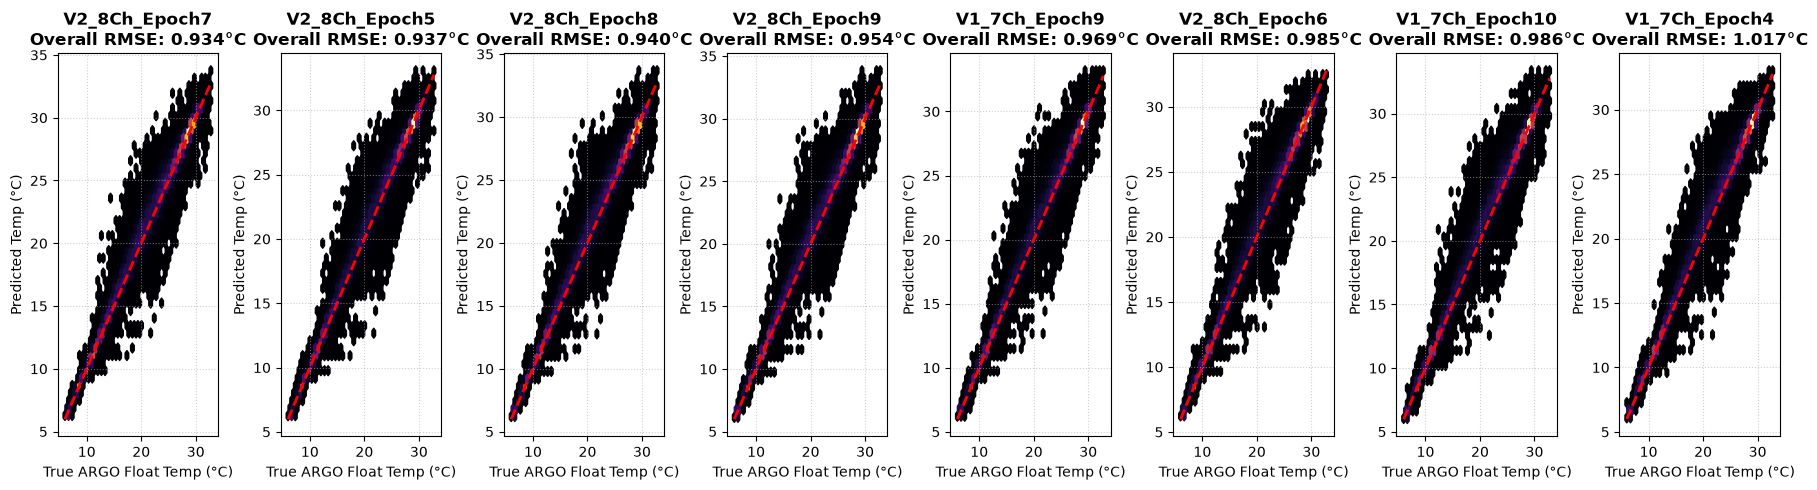

In [18]:
# 1. Print Overall Master Leaderboard
print("=== FINAL OVERALL LEADERBOARD (ALL ARGO DATA) ===")
summary = df_results.groupby('Model').agg(
    RMSE_C=('Error_C', lambda x: np.sqrt((x**2).mean())),
    MAE_C=('Abs_Error_C', 'mean'),
    Max_Error=('Abs_Error_C', 'max'),
    Data_Points=('Model', 'count')
).reset_index().sort_values('RMSE_C')
print(summary.to_string(index=False))

# 2. Plot True vs. Predicted Scatter (Density Heatmap)
plt.figure(figsize=(18, 5))
for i, model_name in enumerate(summary['Model']):
    plt.subplot(1, len(summary), i+1)
    
    m_data = df_results[df_results['Model'] == model_name]
    
    # Use hexbin for dense data to clearly see where the majority of predictions land
    hb = plt.hexbin(m_data['True_C'], m_data['Pred_C'], gridsize=40, cmap='inferno', mincnt=1)
    
    # Plot Ideal 1:1 Line
    min_t, max_t = m_data['True_C'].min(), m_data['True_C'].max()
    plt.plot([min_t, max_t], [min_t, max_t], 'r--', lw=2, label='Ideal 1:1 Line')
    
    rmse = summary[summary['Model'] == model_name]['RMSE_C'].values[0]
    plt.title(f"{model_name}\nOverall RMSE: {rmse:.3f}°C", fontsize=12, fontweight='bold')
    plt.xlabel("True ARGO Float Temp (°C)")
    plt.ylabel("Predicted Temp (°C)")
    plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig("oceanembed_scatter_accuracy.png", dpi=300)
plt.show()

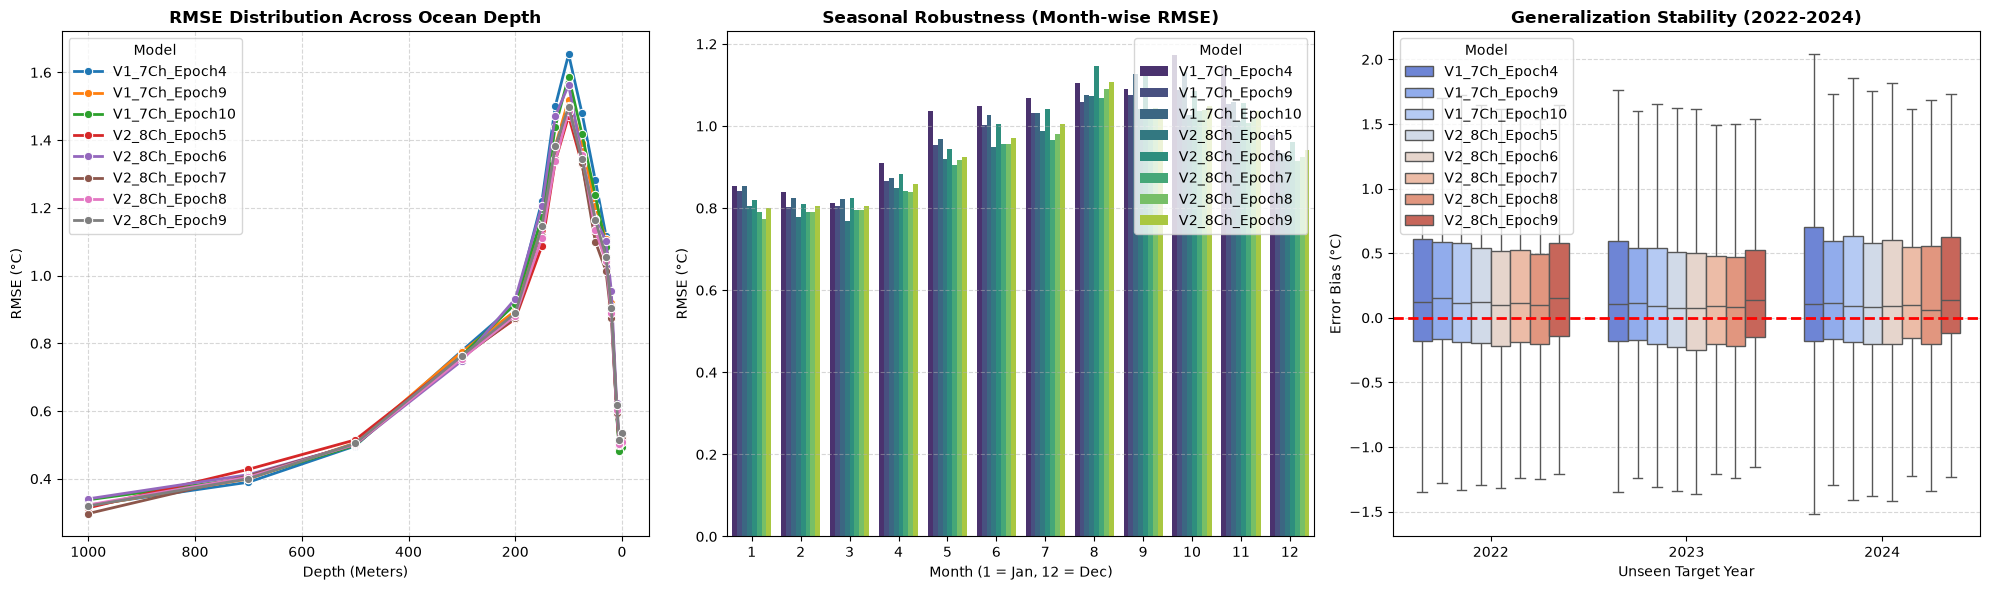

In [19]:
# Actual Depth Mapping from your ocean_mask_3d.nc
DEPTH_MAP = {0:0, 1:5, 2:10, 3:20, 4:30, 5:50, 6:75, 7:100, 8:125, 
             9:150, 10:200, 11:300, 12:500, 13:700, 14:1000}
df_results['Depth_Meters'] = df_results['Depth_Idx'].map(DEPTH_MAP)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- GRAPH 1: RMSE by Depth Level ---
sns.lineplot(
    data=df_results, x='Depth_Meters', y='Abs_Error_C', 
    hue='Model', estimator=lambda x: np.sqrt((x**2).mean()), 
    errorbar=None, ax=axes[0], lw=2, marker='o'
)
axes[0].set_title("RMSE Distribution Across Ocean Depth", fontweight='bold')
axes[0].set_xlabel("Depth (Meters)")
axes[0].set_ylabel("RMSE (°C)")
axes[0].invert_xaxis() # Standard oceanography format (Surface on right or left, depths go down)
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- GRAPH 2: Seasonal (Month-wise) RMSE ---
sns.barplot(
    data=df_results, x='Month', y='Abs_Error_C', 
    hue='Model', estimator=lambda x: np.sqrt((x**2).mean()), 
    errorbar=None, ax=axes[1], palette='viridis'
)
axes[1].set_title("Seasonal Robustness (Month-wise RMSE)", fontweight='bold')
axes[1].set_xlabel("Month (1 = Jan, 12 = Dec)")
axes[1].set_ylabel("RMSE (°C)")
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

# --- GRAPH 3: Year-over-Year Generalization ---
sns.boxplot(
    data=df_results, x='Year', y='Error_C', 
    hue='Model', ax=axes[2], showfliers=False, palette='coolwarm'
)
axes[2].set_title("Generalization Stability (2022-2024)", fontweight='bold')
axes[2].set_xlabel("Unseen Target Year")
axes[2].set_ylabel("Error Bias (°C)")
axes[2].axhline(0, color='red', linestyle='--', lw=2) # 0 Error line
axes[2].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("oceanembed_depth_temporal_analysis.png", dpi=300)
plt.show()

In [20]:
import numpy as np

# Isolate your winning model's data
final_model = 'V2_8Ch_Epoch7'
v2_data = df_results[df_results['Model'] == final_model]

print(f"=== {final_model.upper()} FINAL BENCHMARK REPORT ===")
print(f"Test Set Timeframe: 2022 - 2024")
print(f"Total ARGO Float Measurements: {len(v2_data):,}")
print("-" * 45)

overall_rmse = np.sqrt((v2_data['Error_C']**2).mean())
overall_mae = v2_data['Abs_Error_C'].mean()
print(f"Overall RMSE : {overall_rmse:.4f} °C")
print(f"Overall MAE  : {overall_mae:.4f} °C")
print(f"Max Error    : {v2_data['Abs_Error_C'].max():.4f} °C")

print("\n--- ACCURACY BY DEPTH (Meters) ---")
depth_stats = v2_data.groupby('Depth_Meters').agg(
    Points=('Model', 'count'),
    RMSE_C=('Error_C', lambda x: np.sqrt((x**2).mean())),
    MAE_C=('Abs_Error_C', 'mean')
).sort_index()

# Format the dataframe for clean printing
depth_stats['RMSE_C'] = depth_stats['RMSE_C'].map('{:.4f}'.format)
depth_stats['MAE_C'] = depth_stats['MAE_C'].map('{:.4f}'.format)
print(depth_stats.to_string())

print("\n--- ACCURACY BY YEAR ---")
year_stats = v2_data.groupby('Year').agg(
    Points=('Model', 'count'),
    RMSE_C=('Error_C', lambda x: np.sqrt((x**2).mean())),
    MAE_C=('Abs_Error_C', 'mean')
).sort_index()

year_stats['RMSE_C'] = year_stats['RMSE_C'].map('{:.4f}'.format)
year_stats['MAE_C'] = year_stats['MAE_C'].map('{:.4f}'.format)
print(year_stats.to_string())

=== V2_8CH_EPOCH7 FINAL BENCHMARK REPORT ===
Test Set Timeframe: 2022 - 2024
Total ARGO Float Measurements: 121,008
---------------------------------------------
Overall RMSE : 0.9336 °C
Overall MAE  : 0.5899 °C
Max Error    : 8.8956 °C

--- ACCURACY BY DEPTH (Meters) ---
              Points  RMSE_C   MAE_C
Depth_Meters                        
0               8058  0.5184  0.3317
5               8058  0.4987  0.3161
10              8056  0.5954  0.3391
20              8063  0.8761  0.4792
30              8256  1.0141  0.6194
50              8279  1.1006  0.7472
75              8297  1.3316  0.9795
100             8293  1.4997  1.1621
125             8289  1.3451  1.0614
150             8288  1.1177  0.8666
200             8280  0.8756  0.6315
300             8244  0.7575  0.4679
500             8117  0.5018  0.2718
700             8059  0.4086  0.2411
1000            6371  0.2973  0.2017

--- ACCURACY BY YEAR ---
      Points  RMSE_C   MAE_C
Year                        
2022   41380  